In [ ]:
## CONNECT WITH GOOGLE DRIVE

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
## DATASET LOAD

df_bangla = open("/content/drive/MyDrive/FL paper/Dataset/main bangla corpus dataset.txt").read()

In [ ]:
df_bangla

'\ufeffকর্পোরেশনের দোষ তো আছে । কিন্তু আমরা যে সুযোগ বুঝে হাজার হাজার কোটি টাকার ট্যাক্স ফাকি দিয়ে আসছি সেটাও আমরা জানি । এই ভয়ে সবাই স্যু করার সাহস পাবেনা । কারণ উলটা স্যু সে নিজে খেয়ে যাবে । আপনি স্যু করে দৃষ্টান্ত শুরু করে দিলেই পারেন । অন্যরাও ধীরে ধীরে উৎসাহিত হবে । পরিবর্তন আসবে । আমাদের সবার মনেই বিদেশে পড়তে যাওয়ার সুপ্ত কিন্তু তীব্র আকাঙ্ক্ষা কাজ করে । বিদেশে পড়ার ক্ষেত্রে খরচের ব্যাপারটা মাথায় আসে বলেই আমরা অনেকেই চাই বৃত্তি বা স্কলারশিপ এর ব্যাপারে খোঁজ নিতে । পুরো প্রক্রিয়াটি অনেক বিশদ হওয়ায় আমার ক্ষুদ্র অভিজ্ঞতা থেকে আমি চেষ্টা করবো আমার শিক্ষার্থীদের কিছুটা জানানোর । আমার লেখাটা টি পর্বে থাকবে । আজ প্রথম পর্ব । আজকে আমি আলোচনা করবো বাংলাদেশি শিক্ষার্থীদের জন্য বিদেশে পড়তে যাওয়ার স্কলারশিপ নিয়ে । পরবর্তীতে বিভিন্ন দেশে এপ্লাই করার প্রক্রিয়া ক্রেডিট ট্রান্সফার বিশ্ববিদ্যালয়ের ইন হাউস স্কলারশিপ ইত্যাদি বিষয়ে আলোচনা করবো । যুক্তরাজ্যে পড়তে যাওয়ার জন্য ব্রিটিশ সরকারের বৃত্তি এটি । অত্যন্ত সম্মানজনক এবং সেইসাথে খুবই প্রতিযোগিতামূলক । সাধারণত যারা শিক্ষকতা পেশায় নিয়োজিত থাকেন তার

In [ ]:
import pandas as pd
import numpy as np
import re


from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical



import torch
import torchvision  # torch package for vision related things
import torch.nn.functional as F  # Parameterless functions, like (some) activation functions
import torchvision.datasets as datasets  # Standard datasets
import torchvision.transforms as transforms  # Transformations we can perform on our dataset for augmentation
from torch import optim  # For optimizers like SGD, Adam, etc.
from torch import nn  # All neural network modules
from torch.utils.data import Dataset,DataLoader # Gives easier dataset managment by creating mini batches etc.
from tqdm import tqdm  # For a nice progress bar!
import math
from torch.optim import Adam
from tqdm import tqdm, tqdm_notebook



import collections
from collections import Counter
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from torch.utils.data import TensorDataset
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score


In [ ]:

def replace_strings(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           u"\u00C0-\u017F"          #latin
                           u"\u2000-\u206F"          #generalPunctuations
                               
                           "]+", flags=re.UNICODE)
    english_pattern=re.compile('[a-zA-Z0-9]+', flags=re.I)
    
    
    text=emoji_pattern.sub(r'', text)
    text=english_pattern.sub(r'', text)
    

    return text


def remove_punctuations(my_str):
    # define punctuation
    punctuations = '''````£|¢|Ñ+-*/=EROero৳০১২৩৪৫৬৭৮৯012–34567•89।!()-[]{};:'"“\’,<>./?@#$%^&*_~‘—॥”‰⚽️✌�￰৷￰'''

    
    
    no_punct = ""
    for char in my_str:
        if char not in punctuations:
            no_punct=no_punct+char

        
    no_punct = re.sub('\\s+', ' ', no_punct)
    
    # display the unpunctuated string
    return no_punct





In [ ]:
#df_bangla = remove_punctuations(replace_strings(df_bangla))
df_bangla = replace_strings(df_bangla)


In [ ]:
df_bangla

'কর্পোরেশনের দোষ তো আছে । কিন্তু আমরা যে সুযোগ বুঝে হাজার হাজার কোটি টাকার ট্যাক্স ফাকি দিয়ে আসছি সেটাও আমরা জানি । এই ভয়ে সবাই স্যু করার সাহস পাবেনা । কারণ উলটা স্যু সে নিজে খেয়ে যাবে । আপনি স্যু করে দৃষ্টান্ত শুরু করে দিলেই পারেন । অন্যরাও ধীরে ধীরে উৎসাহিত হবে । পরিবর্তন আসবে । আমাদের সবার মনেই বিদেশে পড়তে যাওয়ার সুপ্ত কিন্তু তীব্র আকাঙ্ক্ষা কাজ করে । বিদেশে পড়ার ক্ষেত্রে খরচের ব্যাপারটা মাথায় আসে বলেই আমরা অনেকেই চাই বৃত্তি বা স্কলারশিপ এর ব্যাপারে খোঁজ নিতে । পুরো প্রক্রিয়াটি অনেক বিশদ হওয়ায় আমার ক্ষুদ্র অভিজ্ঞতা থেকে আমি চেষ্টা করবো আমার শিক্ষার্থীদের কিছুটা জানানোর । আমার লেখাটা টি পর্বে থাকবে । আজ প্রথম পর্ব । আজকে আমি আলোচনা করবো বাংলাদেশি শিক্ষার্থীদের জন্য বিদেশে পড়তে যাওয়ার স্কলারশিপ নিয়ে । পরবর্তীতে বিভিন্ন দেশে এপ্লাই করার প্রক্রিয়া ক্রেডিট ট্রান্সফার বিশ্ববিদ্যালয়ের ইন হাউস স্কলারশিপ ইত্যাদি বিষয়ে আলোচনা করবো । যুক্তরাজ্যে পড়তে যাওয়ার জন্য ব্রিটিশ সরকারের বৃত্তি এটি । অত্যন্ত সম্মানজনক এবং সেইসাথে খুবই প্রতিযোগিতামূলক । সাধারণত যারা শিক্ষকতা পেশায় নিয়োজিত থাকেন তারা এটা 

In [ ]:
tokens = df_bangla.split()

print('Number of words in text file :', len(tokens))

Number of words in text file : 58573


In [ ]:
# organize into sequences of tokens
length = 5
ban_sequences = list()
for i in range(length, len(tokens)):
	# select sequence of tokens
	seq = tokens[i-length:i]
	# convert into a line
	line = ' '.join(seq)
	# store
	ban_sequences.append(line)
print('Total Sequences: %d' % len(ban_sequences))

Total Sequences: 58568


In [ ]:
ban_sequences[:10]

['কর্পোরেশনের দোষ তো আছে ।',
 'দোষ তো আছে । কিন্তু',
 'তো আছে । কিন্তু আমরা',
 'আছে । কিন্তু আমরা যে',
 '। কিন্তু আমরা যে সুযোগ',
 'কিন্তু আমরা যে সুযোগ বুঝে',
 'আমরা যে সুযোগ বুঝে হাজার',
 'যে সুযোগ বুঝে হাজার হাজার',
 'সুযোগ বুঝে হাজার হাজার কোটি',
 'বুঝে হাজার হাজার কোটি টাকার']

In [ ]:
# integer encode sequences of words
tokenizer = Tokenizer()
tokenizer.fit_on_texts(ban_sequences)
sequences = tokenizer.texts_to_sequences(ban_sequences)

sequences=pad_sequences(sequences,padding='pre',maxlen=length)

# vocabulary size
vocab_size = len(tokenizer.word_index) + 1
vocab_size

8626

In [ ]:
sequences[:10]

array([[8625, 3458,   54,   24,    1],
       [3458,   54,   24,    1,   22],
       [  54,   24,    1,   22,   67],
       [  24,    1,   22,   67,   20],
       [   1,   22,   67,   20,  444],
       [  22,   67,   20,  444,  596],
       [  67,   20,  444,  596,  403],
       [  20,  444,  596,  403,  403],
       [ 444,  596,  403,  403, 1377],
       [ 596,  403,  403, 1377, 1031]], dtype=int32)

In [ ]:

x_seq=[]
y_seq=[]

for s in sequences:

  

  x_seq.append(s[:-1])
  y_seq.append(s[-1])




x_seq=np.array(x_seq)
y_seq=np.array(y_seq)




y_seq = to_categorical(y_seq, num_classes=vocab_size)


print(x_seq[0])
print(y_seq[0])

[8625 3458   54   24]
[0. 1. 0. ... 0. 0. 0.]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_seq, y_seq, test_size=0.2, random_state= 42)

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(x_seq, y_seq, test_size=0.1, random_state= 42)

In [ ]:
train_data = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_data = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
valid_data = TensorDataset(torch.from_numpy(X_valid), torch.from_numpy(y_valid))

In [ ]:
train_data[0]

(tensor([2430,   21,    1, 2498], dtype=torch.int32),
 tensor([0., 0., 0.,  ..., 0., 0., 0.]))

In [ ]:
test_data[0]

(tensor([4657, 4658,    1, 2430], dtype=torch.int32),
 tensor([0., 0., 0.,  ..., 0., 0., 0.]))

In [ ]:
valid_data[0]

(tensor([4657, 4658,    1, 2430], dtype=torch.int32),
 tensor([0., 0., 0.,  ..., 0., 0., 0.]))

In [ ]:
train_loader = DataLoader(train_data, shuffle=True, batch_size= 64, drop_last=True) 
valid_loader = DataLoader(valid_data, shuffle=True, batch_size= 64, drop_last=True)
test_loader = DataLoader(test_data, shuffle=True, batch_size= 64, drop_last=True)

In [ ]:
NUM_CLASSES = vocab_size #We are dealing with a multiclass classification of 5 classes
HIDDEN_DIM = 100 #number of neurons of the internal state (internal neural network in the LSTM)
LSTM_LAYERS = 1 #Number of stacked LSTM layers

VOCAB_SIZE=vocab_size
EMBEDDING_DIM = 50

BATCH_SIZE = 64

LR = 3e-4 #Learning rate
DROPOUT = 0.5 #LSTM Dropout
BIDIRECTIONAL = True #Boolean value to choose if to use a bidirectional LSTM or not
EPOCHS = 50 #Number of training epoch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
class BiLSTM_NWP(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, lstm_layers, bidirectional,batch_size, dropout):
        super(BiLSTM_NWP,self).__init__()
        
        self.lstm_layers = lstm_layers
        self.num_directions = 2 if bidirectional else 1
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes
        self.batch_size = batch_size
        

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=lstm_layers,
                            dropout=dropout,
                            bidirectional=bidirectional,
                            batch_first=True)

        self.fc = nn.Linear(hidden_dim*self.num_directions, num_classes)
        self.softmax = nn.LogSoftmax(dim=1)
        
    def forward(self, x, hidden):

        
        self.batch_size = x.size(0)
        ##EMBEDDING LAYER
        embedded = self.embedding(x)
        #LSTM LAYERS
        out, hidden = self.lstm(embedded, hidden)
        #Extract only the hidden state from the last LSTM cell
        out = out[:,-1,:]
        #FULLY CONNECTED LAYERS
        out = self.fc(out)
        out = self.softmax(out)

        return out, hidden

    def init_hidden(self, batch_size):
        #Initialization of the LSTM hidden and cell states
        h0 = torch.zeros((self.lstm_layers*self.num_directions, batch_size, self.hidden_dim)).detach().to(DEVICE)
        c0 = torch.zeros((self.lstm_layers*self.num_directions, batch_size, self.hidden_dim)).detach().to(DEVICE)
        hidden = (h0, c0)
        return hidden

In [ ]:
model = BiLSTM_NWP(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM,NUM_CLASSES, LSTM_LAYERS,BIDIRECTIONAL, BATCH_SIZE, DROPOUT)
model = model.to(DEVICE)



print(model)

BiLSTM_NWP(
  (embedding): Embedding(8626, 50)
  (lstm): LSTM(50, 100, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=200, out_features=8626, bias=True)
  (softmax): LogSoftmax(dim=1)
)


/usr/local/lib/python3.7/dist-packages/torch/nn/modules/rnn.py:65: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  "num_layers={}".format(dropout, num_layers))


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay = 5e-6)

In [ ]:
total_step = len(train_loader)
total_step_val = len(valid_loader)

early_stopping_patience = 4
early_stopping_counter = 0

valid_acc_max = 0 # Initialize best accuracy top 0

train_loss_plot=[]
val_loss_plot=[]

for e in range(EPOCHS):

    #lists to host the train and validation losses of every batch for each epoch
    train_loss, valid_loss  = [], []
    #lists to host the train and validation accuracy of every batch for each epoch
    train_acc, valid_acc  = [], []

    #lists to host the train and validation predictions of every batch for each epoch
    y_train_list, y_val_list = [], []

    #initalize number of total and correctly classified texts during training and validation
    correct, correct_val = 0, 0
    total, total_val = 0, 0
    running_loss, running_loss_val = 0, 0


    ####TRAINING LOOP####

    model.train()

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE) #load features and targets in device

        h = model.init_hidden(labels.size(0))

        model.zero_grad() #reset gradients 

        output, h = model(inputs,h) #get output and hidden states from LSTM network

        
        
        loss = criterion(output, labels)
        loss.backward()
        
        running_loss += loss.item()
        
        optimizer.step()

        y_pred_train = torch.argmax(output, dim=1) #get tensor of predicted values on the training set
        y_train_list.extend(y_pred_train.squeeze().tolist()) #transform tensor to list and the values to the list

        
        y_pred_train = torch.from_numpy(to_categorical(y_pred_train, num_classes=vocab_size))
        
        
        
        correct += torch.sum(y_pred_train==labels).item() #count correctly classified texts per batch
        total += labels.size(0) #count total texts per batch

    train_loss.append(running_loss / total_step)
    train_acc.append(100 * correct / total)

    ####VALIDATION LOOP####
    
    with torch.no_grad():
        
        model.eval()
        
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            val_h = model.init_hidden(labels.size(0))

            output, val_h = model(inputs, val_h)

            val_loss = criterion(output, labels)
            running_loss_val += val_loss.item()

            y_pred_val = torch.argmax(output, dim=1)
            y_val_list.extend(y_pred_val.squeeze().tolist())

            y_pred_val = torch.from_numpy(to_categorical(y_pred_val, num_classes=vocab_size))

            correct_val += torch.sum(y_pred_val==labels).item()
            total_val += labels.size(0)

        valid_loss.append(running_loss_val / total_step_val)
        valid_acc.append(100 * correct_val / total_val)

    #Save model if validation accuracy increases
    if np.mean(valid_acc) >= valid_acc_max:
        torch.save(model.state_dict(), './state_dict.pt')
        print(f'Epoch {e+1}:Validation accuracy increased ({valid_acc_max:.6f} --> {np.mean(valid_acc):.6f}).  Saving model ...')
        valid_acc_max = np.mean(valid_acc)
        early_stopping_counter=0 #reset counter if validation accuracy increases
    else:
        print(f'Epoch {e+1}:Validation accuracy did not increase')
        early_stopping_counter+=1 #increase counter if validation accuracy does not increase
        
    if early_stopping_counter > early_stopping_patience:
        print('Early stopped at epoch :', e+1)
        break
    
    print(f'\tTrain_loss : {np.mean(train_loss):.4f} Val_loss : {np.mean(valid_loss):.4f}')
    print(f'\tTrain_acc : {np.mean(train_acc):.3f}% Val_acc : {np.mean(valid_acc):.3f}%')
    train_loss_plot.append(np.mean(train_loss))
    val_loss_plot.append(np.mean(valid_loss))

Epoch 1:Validation accuracy increased (0.000000 --> 862414.423077).  Saving model ...
	Train_loss : 7.9959 Val_loss : 7.6976
	Train_acc : 862413.214% Val_acc : 862414.423%
Epoch 2:Validation accuracy increased (862414.423077 --> 862415.006868).  Saving model ...
	Train_loss : 7.3295 Val_loss : 7.4727
	Train_acc : 862414.759% Val_acc : 862415.007%
Epoch 3:Validation accuracy increased (862415.006868 --> 862415.968407).  Saving model ...
	Train_loss : 6.8566 Val_loss : 7.1460
	Train_acc : 862415.796% Val_acc : 862415.968%
Epoch 4:Validation accuracy increased (862415.968407 --> 862418.715659).  Saving model ...
	Train_loss : 6.2772 Val_loss : 6.8319
	Train_acc : 862418.480% Val_acc : 862418.716%
Epoch 5:Validation accuracy increased (862418.715659 --> 862422.252747).  Saving model ...
	Train_loss : 5.7020 Val_loss : 6.5365
	Train_acc : 862423.660% Val_acc : 862422.253%
Epoch 6:Validation accuracy increased (862422.252747 --> 862426.201923).  Saving model ...
	Train_loss : 5.1728 Val_loss

In [ ]:
model

BiLSTM_NWP(
  (embedding): Embedding(8626, 50)
  (lstm): LSTM(50, 100, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=200, out_features=8626, bias=True)
  (softmax): LogSoftmax(dim=1)
)

In [ ]:
# Loading the best model
model.load_state_dict(torch.load('./state_dict.pt'))

<All keys matched successfully>

In [35]:
print(train_loss_plot)
print(val_loss_plot)

[7.99590611023283, 7.329533182401414, 6.856598284525541, 6.277192910126029, 5.7020027397035244, 5.172811737037371, 4.701878553752041, 4.286856353789894, 3.9245667839977316, 3.6113609340616737, 3.3349113319508215, 3.0881507897869493, 2.8662048058260687, 2.6658230933065403, 2.4858863437740655, 2.322010735405172, 2.1724711262585905, 2.0340449420388964, 1.9064817102682547, 1.7879580068124745, 1.6771615440906325, 1.5738323067981446, 1.4772165054104598, 1.3859120621860823, 1.3002523289561128, 1.2193849030271047, 1.1426996450377844, 1.072074514692638, 1.0045309962652724, 0.9411183883903383, 0.8811214021605102, 0.8247680357348441, 0.7714230782858221, 0.7209135213208228, 0.6733896558875736, 0.6287769776285781, 0.5868146554957329, 0.5472156459947692, 0.5100200464847167, 0.4753922698600614, 0.4421716977911181, 0.4109372472886182, 0.38218946868999615, 0.35497813929836486, 0.329488451596019, 0.30554626515431654, 0.2826781319691952, 0.26203491869195844, 0.24230242889025955, 0.22380503756814565]
[7.6

In [ ]:
import matplotlib.pyplot as plt

def plot(loss_train,loss_val):




        print(f"\n Training loss Plot \n")
        
        plt.plot(loss_train, color='g', label="Training Loss")
        
        plt.title('Model Training Loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Training Loss'], loc='upper right')
        plt.show()
        
        print(f"\n---------------------------------\n")

        print(f"\n Validation Loss Plot \n")

        plt.plot(loss_val, color='g', label="Validation Loss")
        
        plt.title('Model validation Loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Validation Loss'], loc='upper right')
        plt.show()
        
        print(f"\n---------------------------------\n")


 Training loss Plot 



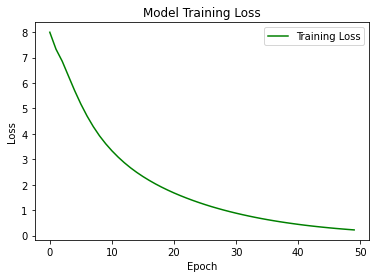


---------------------------------


 Validation Loss Plot 



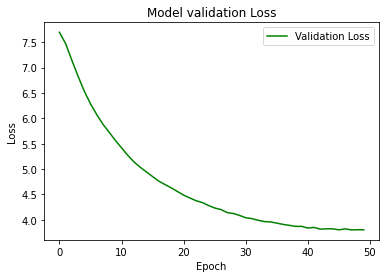


---------------------------------



In [ ]:
plot(train_loss_plot,val_loss_plot)

In [ ]:
import tensorflow as tf


model.eval()
y_pred_list = []
y_test_list = []
for inputs, labels in test_loader:
    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
    test_h = model.init_hidden(labels.size(0))

    output, val_h = model(inputs, test_h)
    y_pred_test = torch.argmax(output, dim=1)
    y_pred_list.extend(y_pred_test.squeeze().tolist())
    y_test_list.extend(labels.squeeze().tolist())


y_test_list = tf.math.argmax(y_test_list, axis=1)


In [ ]:
y_pred_list[:10]

[160, 1143, 21, 2248, 31, 1811, 8, 5928, 17, 125]

In [ ]:
y_test_list[:10]

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([ 160, 1143,    7, 2248,   31, 1811,    8, 5928, 3239,  125])>

In [ ]:
my_dict = {}

# Prediction



my_dict['Accuracy'] = round(accuracy_score(y_test_list, y_pred_list) ,4)*100 
my_dict['Precision'] = round(precision_score(y_test_list, y_pred_list,average='macro',zero_division=1),4)*100 
my_dict['Recall'] = round(recall_score(y_test_list, y_pred_list,average='macro',zero_division=1),4)*100 
my_dict['F1 Score'] = round(f1_score(y_test_list, y_pred_list,average='macro',zero_division=1),4)*100 

print(my_dict)

{'Accuracy': 83.05, 'Precision': 93.52000000000001, 'Recall': 85.75, 'F1 Score': 82.77}


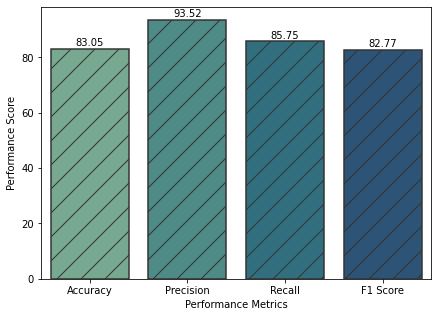

In [ ]:
import seaborn as sns




df=pd.DataFrame({'Performance Metrics': ['Accuracy','Precision','Recall','F1 Score'], 'Performance Score': [my_dict['Accuracy'], my_dict['Precision'], my_dict['Recall'], my_dict['F1 Score']]})

plt.figure(figsize=(7,5))

ax= sns.barplot(x="Performance Metrics",y="Performance Score",data=df,order=['Accuracy','Precision','Recall','F1 Score'],edgecolor="0.2",linewidth=1.5,palette="crest",hatch="/",)


for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 6), textcoords = 'offset points')